# AMME5710 Week 7 Tutorial

This activity is to be completed during the Week 7 tutorial. When you have completed the activity, you will need to show your results to the tutor who will check your work and that you have sufficiently completed the task: this needs to be completed during the tutorial time, so make sure you are ready to show the tutors your work during the last hour of the tutorial.

**Tutorial Objectives and Instructions**:
- This tutorial aims to give you an introduction into image classification using supervised machine learning algorithms. In this tutorial, we focus on feature extraction, model training and validation for the task of image classification for recognising handwritten digits.
- You should step through the example code snippets which explain and demonstrate the use of relevant functions in OpenCV.
- At the end of the notebook, there are several activities/exercises you will need to complete yourself. You can choose to:
    - Complete these inside the tutorial Jupyter Notebook using python code blocks
    - Write your own python code/scripts to produce the results requested

At any time, you can review the OpenCV documentation [https://docs.opencv.org/4.9.0/index.html](https://docs.opencv.org/4.9.0/index.html)l


In [1]:
# Import required modules
import cv2
import numpy as np 
from matplotlib import pyplot as plt
%matplotlib inline 

## 1. MNIST Hand-written Digits Dataset

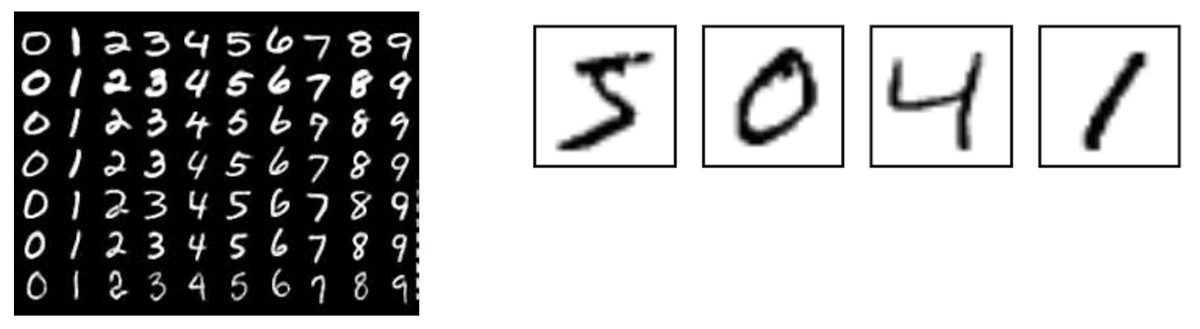

The MNIST Hand-written Digits Dataset [1] contains a large number of image examples of the digits 0 to 9 written by various people. Each example is a 28x28 grayscale image of a given digit. The dataset is broken down in a training portion (with 60,000 examples) and a testing portion (with 10,000 examples). The dataset was originally used to train models to identify digits that were hand-written when filling out the US national census, and later for a variety of different text recognition applications.

The dataset can be accessed via the Week 7 Canvas modules page ("MNIST_dataset.zip") which contains a python pickle file. Inside the pickle file is a dictionary with the fields:
- **data_train**: 28x28xK array containing the K images used during training of the machine learning algorithm for classification. Each layer in the array represents an individual image sample.
- **labels_train**: Kx1 dimensional array containing the label of the corresponding image in "data_train".
- **data_test**: 28x28xP matrix containing the P images used during the final testing of the algorithm. These images are not used during training, and are instead used as independant examples to test/evaluate the final trained model performance.
- **labels_test**: Px1 dimensional vector containing the label of the corresponding image in "data_test".

The following code loads the dataset and shows and example image and label:

[1] MNIST Database: http://yann.lecun.com/exdb/mnist/

Digit label for index 0 of training data:  5


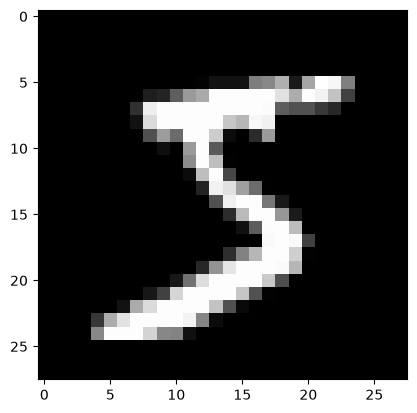

In [2]:
import pickle

# Load MNIST data
mnist_data = pickle.load( open( 'MNIST_dataset.pkl', "rb" ) )

ind = 0 # index of training samples
img_float = mnist_data['data_train'][:,:,ind] # image data stored as float 0.0-1.0
label = mnist_data['labels_train'][ind,0]

plt.imshow(img_float, 'gray') # show using grayscale colourmap

print('Digit label for index %d of training data: '%(ind), label)

In this tutorial we will train a classifier to recognise/classify each image example into one of the possible ten digits. To do this, we will provide a portion of the training dataset inputs (image data) and output (classes/digit labels) to a supervised classificaiton algorithm, and train the algorithm to recognise digits from new, unseen images.

# 2. Data Preparation and training data selection

When training a classification model, we also typically wish to understand how well the model will perform on new, unseen examples which will be provided to the model when it is used. We therefore begin by reserving a portion of our total available data for testing by spliting our pool of data into a "testing" and "training" split.

MNIST is already organised in this way for you (60,000 training examples and 10,000 testing examples), however if you collect your own data for developing a classification model, you would need to choose your own splits that are relevant for your task. Ideally, the resulting test and train splits of the data contain a wide range of examples which are representative samples of the types of expected input data that the model will need to make predictions on.

Ideally a training dataset should also be "balanced": that is, an equal proportion of examples are provided to the classifier of the different digits/classes to be identified. The MNIST dataset is a well-balanced dataset, in that there are a relatively equal number of each digit, which we can see by plotting a histogram of the class values:

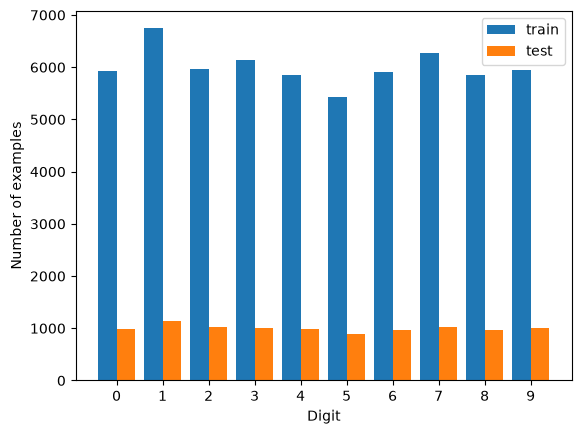

In [3]:
# Examine how many traing/testing examples we have of each class

(hist_train, bins) = np.histogram(mnist_data['labels_train'], bins=10)
(hist_test, bins) = np.histogram(mnist_data['labels_test'], bins=10)

plt.bar(np.arange(10)-0.2, hist_train, align='center', width=0.4)
plt.bar(np.arange(10)+0.2, hist_test, align='center', width=0.4)
plt.xticks(np.arange(10))
plt.xlabel('Digit')
plt.ylabel('Number of examples')
plt.legend(['train','test']);
plt.show()

# 3. Extracting features from the image data

"Features" are a lower dimensional representation of the image data that capture the key properties of an image that could help distinguish the different classes in the dataset. Some potential features from image data could be:
- Average colour or grayscale values
- Histograms of the image data
- Average colours or histograms calculated over different spatial regions of the image
- Filtered outputs of the image
- Down-sampled image data
- The raw pixel/image data itself

Calculating features (rather than using the raw image data itself as a feature) serves to reduce the dimension of data coming into the input to the model. As a general rule of thumb, the larger the dimension of the input, the larger the amount of training data that is going to be required to train a robust model given the same amount of model parameters.

## Histogram of Oriented Gradient (HOG) Features

One type of feature often used for image classification and object detection purposes are Histograms of Oriented Gradients (HOG) features [2]. HOG features break the image up into a number of "cells" (smaller square regions) and summarise a histogram of the direction of the gradient vectors for each pixel in each cell. These histograms have shown to be an effective descriptor for many image-based tasks including classification (features were originally demonstrated as be effective in an image-based person detection algorithm in [2]).

HOG features are calculated by:
1. Calculate the gradient direction of each image pixel, for example using a Sobel filter.
2. Break the image into square cells (for example of 4x4 or 8x8 pixels), and for each cell calculate a histogram of the orientations.
3. Normalise the histogram values in each cell by using the values found in other cells within a "block" (a square grid of cells, for example a sinlg eblock might contain 2x2 cells.

OpenCV provide a function "cv2.HOGDescriptor" which can be used to extract HOG features:
```
hog = cv2.HOGDescriptor(_winSize,_blockSize,_blockStride,_cellSize,_nbins)
```
"_cellSize" is the size of each cell, "_blockSize" is the size of each block (both specified in pixels) and "_nbins" is the number of bins to use in the histogram. "_blockStride" is used to specify the number of pixels to shift left and down for each box calculation. Calculations can be performed over a window which contains multiple blocks, which is specified by "_winSize" in pixels. 

Features are then calculated using:
```
hog_feats = hog.compute(img)
```
where "img" is a grayscale image with values between 0-255. For each possible window (scanned across the image), each possible block is scanned through inside the window, using the stride specified, and histograms of each cell are provided, normalised to the current block.

The below code block illustrates a potential way of extracting HOG features from one of the MNIST images.

[2] N. Dalal, B. Triggs, C. Schmid, "Human Detection Using Oriented Histograms of Flow and Appearance", ECCV 2006.

In [4]:
# Example HOG feature extraction

# create HOG object for extracting features
# In this example, the windowsize will be equal to the image dimensions (28x28)
# We will work iwth a cell size of 7x7 pixel (i.e. the image is broken up into 4x4 cells)
# A block size of 14x14 means each block will contain 2x2 cells (used for normalisation)
# The block stride of 7x7 means blocks will be sampled every 7 pixels (i.e. with a 50% overlap)
# We will use 9 bins for each gradient orientation histogram
hog = cv2.HOGDescriptor(_winSize=(28,28),_blockSize=(14,14),_blockStride=(7,7),_cellSize=(7,7),_nbins=9)

# select an image and convert to uint8
ind = 0
img_float = mnist_data['data_train'][:,:,ind]
img = (255*img_float).astype('uint8')

# extract HOG features
hog_feats = hog.compute(img)
print("HOG feature dimension:", hog_feats.shape)


HOG feature dimension: (324,)


In this example, a 324-dimension feature is returned. Each block contains 4 cells, each of which has 9 bins. Given a block size of 14x14, and blocks calculated every 7x7 pixels, we can sample a total of 3x3=9 block locations in the 28x28 image. So the total number of features returned is 9x4x9=324 features.

Variations in the cell and block size will change the total number of features and different combinations will work better or worse (in terms of classification performs) depending on the image properties and task itself (for example, the original HOG paper [2] use 9 bins, a cell size of 8x8 and a block size of 16x16, calculated over a sampling window of 64x128 pixels for detecting/classifying people in images.

# 4. Classifier Model Functions in scikit-learn

In this tutorial we will use a variety of classifier models which are implemented in the python library "Scikit-learn". Scikit-learn (https://scikit-learn.org/) is a python based library that implements a number of machine learning algorithms that can be used for classification, regression and data clustering.

Scikit-learn can be installed using pip (i.e. "pip install scikit-learn"), and is imported using "import sklearn".

# Support Vector Machine (SVM)

sklearn implements a SVM classifier in the module "sklearn.svm.SVC" which can be used to train a multi-class classification model. The model is initialised using:
```
clf = sklearn.svm.SVC()
```
which initialises a model using the default parameters. Some parameters which might be useful when tuning your classification algorithm include "C", which controls the regularisation of the model, "kernel" which changes the kernel type used and "gamma" which is the kernel coefficient used.

Once a model has been initialised, you train the model using the method "fit":
```
clf.fit(X_train, y_train)
```
where "X_train" is an array of training input data with dimensions (number of examples, number of features) and "y_train" is an array of corresponding training outputs (i.e. digit/class values). Depending on the training size, the training/fitting process may take a while to complete (up to a few minutes).

Once the model has been trained, you can perform predictions on new image samples by calling the method "predict":
```
y_pred = clf.predict(X_test)
```
where "X_test" array of testing input data with dimensions (number of examples, number of features).

Further details on the function can be found in the documentation at https://scikit-learn.org/stable/modules/svm.html#classification.

# KNN Classification

sklearn also implements a K-Nearest Neighbours (KNN) classifier:
```
neigh = sklearn.neighbors.KNeighborsClassifier()
```
which initialises a model using the default parameters. Like other classifiers, there are several parameters to the model that can be specified. The most important of htese for a KNN classifier is the vallue of K to use, which is specified by the input parameter "n_neighbors".

As is the case for the SVM classifier, you can also call the functions "fit" and "predict" on an initialised object "neigh".

Further details on the function can be found in the documentation at
https://scikit-learn.org/stable/modules/neighbors.html#nearest-neighbors-classification

In [5]:
# import relevant modules from scikit-learn
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


# 4. Measuring Classification Performance

Measuring the performance of a classifier on an independant test set of data (i.e. data not seen by the model at training time) is a key component in model development. During the Week 7 lecture we explored several metrics for measuring classification performance for both binary and multi-class classification tasks.

sklearn contains various functions in the module "sklearn.metrics" which can be used to calculate performance metrics. Most functions take one array of the predicted values of classes from a given model/classifier and a second array containing the know ground truth classes in order to calculate metrics such as accuracy, precision, recall, f1 score etc.

During this tutorial, you will also be writing your own functions to compute metrics: a good way to understand what a metric measures and how it works is to implement it yourself! You can also use the functions in "sklearn.metrics" to check your functions are working as intended.

# Exercise/Activities to Complete
The following activities should be completed during the Friday tutorial and shown to your tutor to be marked off.


In the following exercises, you will build and train a classifier to recognise/classify digits from the images using the MNIST dataset. You will be training and evaluating/testing models while examining effects such as the amount of training data used and the type of features extracted from the data.

## Exercise 1: MNIST Digit Classification: Data Preparation

- Write a function which selects a random portion of N training examples (pairs of image data and corresponding known labels), which contains a balanced sample of each of the 10 possible digits available.


Selected data shape: (28, 28, 10)
Selected labels shape: (10,)


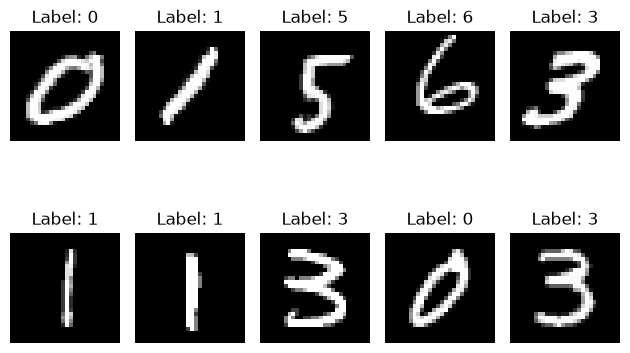

In [6]:
# Write your code here, or in a separate python script
def select_train_sample(N: int, data: np.ndarray, labels: np.ndarray):
    """
    Selects N random samples from the training data and returns the corresponding images and labels.
    
    Parameters:
    N (int): Number of samples to select
    data (np.ndarray): The training data (images)
    labels (np.ndarray): The corresponding labels for the training data
    
    Returns:
    selected_data (np.ndarray): The selected images
    selected_labels (np.ndarray): The corresponding labels for the selected images
    """
    # Randomly select N indices from the range of available samples
    indices = np.random.choice(data.shape[2], N, replace=False)
    
    # Select the corresponding images and labels
    selected_data = data[:, :, indices]
    selected_labels = labels[indices, 0]
    
    return selected_data, selected_labels

# Load MNIST data
mnist_data = pickle.load( open( 'MNIST_dataset.pkl', "rb" ) )

img_float = mnist_data['data_train']
label = mnist_data['labels_train']

selected_data, selected_labels = select_train_sample(10, img_float, label)

for i in range(selected_data.shape[2]):
    plt.subplot(2, 5, i+1)
    plt.imshow(selected_data[:, :, i], cmap='gray')
    plt.title(f"Label: {selected_labels[i]}")
    plt.axis('off')
plt.tight_layout()
print("Selected data shape:", selected_data.shape)
print("Selected labels shape:", selected_labels.shape)


## Exercise 2: MNIST Digit Classification: Feature Extraction

- Choose a set of potential features to extract from each image and write a function (or several functions, one for each choice of features) which takes in an image example, calculates features and returns a feature vector.


In [13]:
# Write your code here, or in a separate python script
def extract_hog_features(data: np.ndarray):
    """
    Extracts HOG features from the given image data.
    
    Parameters:
    data (np.ndarray): The image data (images)
    
    Returns:
    hog_features (np.ndarray): The extracted HOG features
    """
    # Create HOG object for extracting features
    hog = cv2.HOGDescriptor(_winSize=(28,28),_blockSize=(14,14),_blockStride=(7,7),_cellSize=(7,7),_nbins=9)
    
    # Initialize an empty list to store HOG features
    hog_features = []
    
    # Loop through each image in the data
    for i in range(data.shape[2]):
        img_float = data[:, :, i]
        img = (255 * img_float).astype('uint8')  # Convert to uint8
        
        # Extract HOG features
        hog_feats = hog.compute(img)
        
        # Append the features to the list
        hog_features.append(hog_feats.flatten())
    
    return np.array(hog_features)

def pixel_intensity_features(data: np.ndarray):
    """
    Extracts pixel intensity features from the given image data.
    """
    pixel_features = []

    for i in range(data.shape[2]):
        image = data[:, :, i]
        pixel_features.append(image.flatten())

    return np.array(pixel_features)

random_index = np.random.randint(0, 10)

hog_features = extract_hog_features(selected_data)
pixel_features = pixel_intensity_features(selected_data)

print("HOG features shape:", hog_features.shape)
print("Pixel intensity features shape:", pixel_features.shape)

HOG features shape: (10, 324)
Pixel intensity features shape: (10, 784)


## Exercise 3: MNIST Digit Classification: Model Training

- Train a classification model (either an SVM or KNN) to recognitse MNIST digits.
- Start by training a model that uses a random sample of N=10,000 training examples and any one of the sets of feature extraction functions you have written in Exercise 2.
- Use your trained model to predict the class of one or a few of the examples in the test set, and show your predicted output.


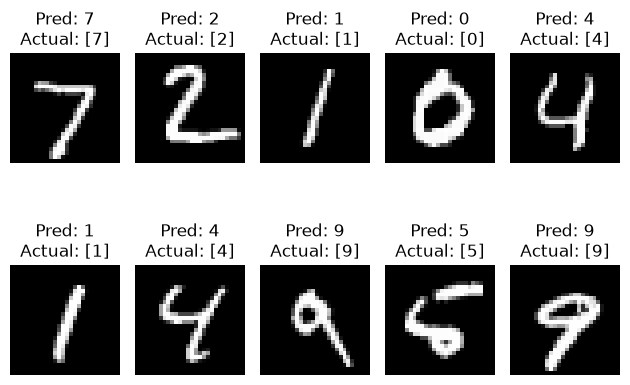

In [8]:
# Write your code here, or in a separate python script
def train_classifier(classifier, data_train, labels_train):
    """
    Train a classifier using the training data and labels.
    
    Parameters:
    classifier: An instance of a scikit-learn classifier (e.g., SVC, KNeighborsClassifier).
    data_train: A 2D numpy array where each row is a feature vector for a training sample.
    labels_train: A 1D numpy array containing the labels for the training samples.
    
    Returns:
    The trained classifier.
    """
    # Fit the classifier to the training data
    classifier.fit(data_train, labels_train)
    
    return classifier

def select_classifier(classifier_type: str):
    """
    Selects and returns a classifier based on the specified type.
    
    Parameters:
    classifier_type (str): The type of classifier to select ('SVM' or 'KNN').
    
    Returns:
    An instance of the selected classifier.
    """
    if classifier_type == 'SVM':
        return SVC(kernel='linear', C=1.0)
    elif classifier_type == 'KNN':
        return KNeighborsClassifier(n_neighbors=3)
    else:
        raise ValueError("Unsupported classifier type. Choose 'SVM' or 'KNN'.")

select_data, select_labels = select_train_sample(10000, mnist_data['data_train'], mnist_data['labels_train'])
hog_features = extract_hog_features(select_data)

classifier_type = 'SVM'  # Change to 'KNN' to use K-Nearest Neighbors
classifier = select_classifier(classifier_type)
trained_classifier = train_classifier(classifier, hog_features, select_labels)

test_data = mnist_data['data_test']
test_labels = mnist_data['labels_test']
test_features = extract_hog_features(test_data)

test_index = 0

prediction = trained_classifier.predict(
    test_features[test_index].reshape(1, -1)
)

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(test_data[:, :, i], cmap='gray')
    plt.title(f"Pred: {trained_classifier.predict(test_features[i].reshape(1, -1))[0]}\nActual: {mnist_data['labels_test'][i]}")
    plt.axis('off')
plt.tight_layout()

## Exercise 4: Classifer Performance Metrics

- Write a function that calculates performance metrics by taking in one array that represents a series of predicted classes and a second array which contains the corresponding know ground truth class values.
- Your function should return:
    - A confusion matrix (10x10 matrix)
    - overall accuracy (scalar)
    - precision (per class, a 10x1 array)
    - recall (per class, a 10x1 array)
    - f1 score (per class, a 10x1 array)
- You must perform calculations using standard numpy array functions only, and may not use any functions for pre-calculating these values in sklearn or other python packages.
- Use your function and trained model from Exercise 3 to compute the performance metrics of your model using the 10,000 available test examples for the MNIST dataset.
- Display your performance metrics: which digits are the easiest/most difficult to classify? When do differernt digits get confused (see your confusion matrix)?
- Find some specific test examples that your classifier predicted correctly vs. incorrectly: why might these be this way?

In [9]:
# Write your code here, or in a separate python script
def calculate_metrics(predicted, ground_truth):
    """
    Calculate confusion matrix, accuracy, precision, recall and F1 score.

    Parameters:
    predicted: 1D numpy array of predicted class labels
    ground_truth: 1D numpy array of true class labels

    Returns:
    confusion_matrix: 10x10 numpy array
    accuracy: scalar
    precision: 10x1 numpy array
    recall: 10x1 numpy array
    f1_score: 10x1 numpy array
    """

    # Initialise confusion matrix
    confusion_matrix = np.zeros((10, 10), dtype=int)

    # Fill confusion matrix
    for actual, prediction in zip(ground_truth, predicted):
        confusion_matrix[actual, prediction] += 1

    # Overall accuracy
    accuracy = np.sum(np.diag(confusion_matrix)) / np.sum(confusion_matrix)

    # Initialise metric arrays
    precision = np.zeros(10)
    recall = np.zeros(10)
    f1_score = np.zeros(10)

    for digit in range(10):

        # True positives
        TP = confusion_matrix[digit, digit]

        # False positives
        FP = np.sum(confusion_matrix[:, digit]) - TP

        # False negatives
        FN = np.sum(confusion_matrix[digit, :]) - TP

        # Precision
        if TP + FP > 0:
            precision[digit] = TP / (TP + FP)

        # Recall
        if TP + FN > 0:
            recall[digit] = TP / (TP + FN)

        # F1 score
        if precision[digit] + recall[digit] > 0:
            f1_score[digit] = (
                2 * precision[digit] * recall[digit]
                / (precision[digit] + recall[digit])
            )

    return confusion_matrix, accuracy, precision, recall, f1_score

predicted_labels = trained_classifier.predict(test_features)

true_labels = mnist_data['labels_test']

confusion_matrix, accuracy, precision, recall, f1_score = calculate_metrics(
    predicted_labels,
    true_labels
)

print("Confusion Matrix:")
print(confusion_matrix)

print("\nAccuracy:")
print(accuracy)

print("\nPrecision:")
print(precision)

print("\nRecall:")
print(recall)

print("\nF1 Score:")
print(f1_score)

Confusion Matrix:
[[ 977    0    1    0    0    0    2    0    0    0]
 [   0 1125    4    0    2    0    2    1    1    0]
 [   3    6 1013    1    0    0    0    8    1    0]
 [   0    1    0  996    0    5    0    3    4    1]
 [   0    2    1    0  966    0    4    2    1    6]
 [   0    0    0    8    0  878    1    0    5    0]
 [   7    2    0    0    1    5  942    0    1    0]
 [   0    3    8    2    3    0    0 1009    1    2]
 [   4    1    4    5    1    2    0    1  952    4]
 [   0    3    0    1    5    1    0    7    9  983]]

Accuracy:
0.9841

Precision:
[0.98587286 0.98425197 0.98254122 0.98321816 0.98773006 0.98540965
 0.99053628 0.97866149 0.97641026 0.98694779]

Recall:
[0.99693878 0.99118943 0.98158915 0.98613861 0.98370672 0.98430493
 0.98329854 0.98151751 0.97741273 0.97423191]

F1 Score:
[0.99137494 0.98770852 0.98206495 0.98467622 0.98571429 0.98485698
 0.98690414 0.98008742 0.97691124 0.98054863]


## Exercise 5: Studying Classifier Performance

- Use your functions developed in Exercises 1-4 above to assess the impact of the number of available training examples on classifier model performance:
    - collect N random training examples for N=[60000, 10000, 5000, 1000, 500, 100] (six groups of data)
    - For each training set, train a model of your choice
    - Evaluate the performance of the model using all of the 10,000 test examples
    - Produce a plot of overall classifier accuracy vs. training size
- Repeat the experiment detailled above for different choices in (a) different feature extraction methods and (b) classifier (i.e. SVM vs. KNN) (c) classifier parameters (e.g. C, K etc.)
- Produce plots of the effect of some of these variables on overall classifier performance (e.g. accuracy)



Training size: 60000
Pixel + SVM: 94.04%
HOG + SVM: 98.89%
Pixel + KNN: 97.05%
HOG + KNN: 98.68%

Training size: 10000
Pixel + SVM: 91.74%
HOG + SVM: 98.62%
Pixel + KNN: 94.82%
HOG + KNN: 97.77%

Training size: 5000
Pixel + SVM: 91.93%
HOG + SVM: 98.24%
Pixel + KNN: 93.66%
HOG + KNN: 97.40%

Training size: 1000
Pixel + SVM: 88.69%
HOG + SVM: 97.33%
Pixel + KNN: 87.98%
HOG + KNN: 95.41%

Training size: 500
Pixel + SVM: 86.47%
HOG + SVM: 96.19%
Pixel + KNN: 83.91%
HOG + KNN: 93.50%

Training size: 100
Pixel + SVM: 75.20%
HOG + SVM: 90.70%
Pixel + KNN: 65.37%
HOG + KNN: 82.89%


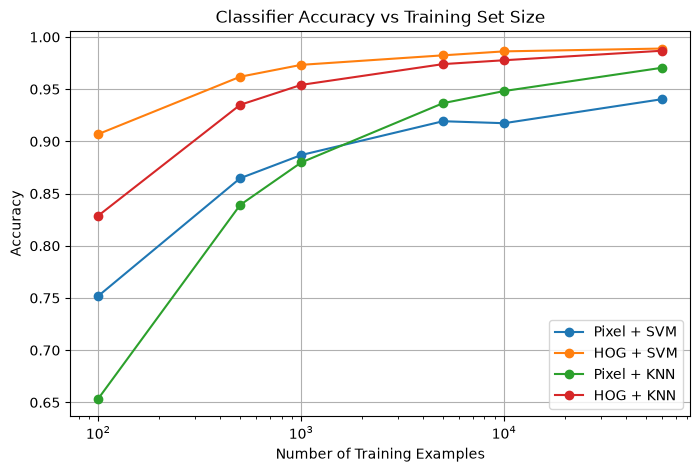

In [20]:
# Training sizes
training_sizes = [60000, 10000, 5000, 1000, 500, 100]

# Extract test features once
test_hog_features = extract_hog_features(mnist_data['data_test'])
test_pixel_features = pixel_intensity_features(mnist_data['data_test'])
test_labels = mnist_data['labels_test']


# Store results
results = {
    'Pixel + SVM': [],
    'HOG + SVM': [],
    'Pixel + KNN': [],
    'HOG + KNN': []
}


for N in training_sizes:
    print(f"\nTraining size: {N}")

    # ---------------------------------------------------------
    # Select random training examples
    # ---------------------------------------------------------
    train_data, train_labels = select_train_sample(
        N,
        mnist_data['data_train'],
        mnist_data['labels_train']
    )

    # ---------------------------------------------------------
    # Extract both types of features
    # ---------------------------------------------------------
    train_pixel_features = pixel_intensity_features(train_data)
    train_hog_features = extract_hog_features(train_data)

    # ---------------------------------------------------------
    # Pixel + SVM
    # ---------------------------------------------------------
    svm = SVC(kernel='linear', C=1.0)

    svm.fit(train_pixel_features, train_labels)

    predicted = svm.predict(test_pixel_features)

    _, accuracy, _, _, _ = calculate_metrics(
        predicted,
        test_labels
    )

    results['Pixel + SVM'].append(accuracy)

    print(f"Pixel + SVM: {accuracy * 100:.2f}%")


    # ---------------------------------------------------------
    # HOG + SVM
    # ---------------------------------------------------------
    svm = SVC(kernel='linear', C=1.0)

    svm.fit(train_hog_features, train_labels)

    predicted = svm.predict(test_hog_features)

    _, accuracy, _, _, _ = calculate_metrics(
        predicted,
        test_labels
    )

    results['HOG + SVM'].append(accuracy)

    print(f"HOG + SVM: {accuracy * 100:.2f}%")


    # ---------------------------------------------------------
    # Pixel + KNN
    # ---------------------------------------------------------
    knn = KNeighborsClassifier(n_neighbors=3)

    knn.fit(train_pixel_features, train_labels)

    predicted = knn.predict(test_pixel_features)

    _, accuracy, _, _, _ = calculate_metrics(
        predicted,
        test_labels
    )

    results['Pixel + KNN'].append(accuracy)

    print(f"Pixel + KNN: {accuracy * 100:.2f}%")


    # ---------------------------------------------------------
    # HOG + KNN
    # ---------------------------------------------------------
    knn = KNeighborsClassifier(n_neighbors=3)

    knn.fit(train_hog_features, train_labels)

    predicted = knn.predict(test_hog_features)

    _, accuracy, _, _, _ = calculate_metrics(
        predicted,
        test_labels
    )

    results['HOG + KNN'].append(accuracy)

    print(f"HOG + KNN: {accuracy * 100:.2f}%")
    
plt.figure(figsize=(8, 5))

for method, accuracies in results.items():
    plt.plot(
        training_sizes,
        accuracies,
        marker='o',
        label=method
    )

plt.xlabel("Number of Training Examples")
plt.ylabel("Accuracy")
plt.title("Classifier Accuracy vs Training Set Size")
plt.xscale("log")
plt.legend()
plt.grid(True)
plt.show()